**1: Project Introduction Fake News Detection using BERT**

## Problem Statement

Fake news spreads quickly on social media and news platforms. Traditional machine learning models rely heavily on manual feature engineering and often fail to understand the semantic meaning of text.

In this project, we use BERT (Bidirectional Encoder Representations from Transformers), a transformer-based deep learning model, to classify news articles as Real or Fake.

## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Transformers (Hugging Face)
- PyTorch
- Scikit-learn
- Matplotlib
- Seaborn

## Deep Learning Model

- bert-base-uncased

# 2: Install Libraries

In [ ]:
!pip install transformers datasets accelerate -q
# #We need:

# transformers → Loads pretrained BERT models.
# datasets → Optional utility for datasets.
# accelerate → Speeds up model training.

# **3: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import torch

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from transformers import BertTokenizer

# Explain each import:

# pandas → Reads CSV.
# numpy → Numerical operations.
# torch → Deep Learning framework.
# transformers → Loads BERT.
# train_test_split → Splits the dataset.

# **4: Load Dataset**

In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv", nrows=5)
print(fake)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [ ]:
import os

print(os.path.getsize("Fake.csv"))
print(os.path.getsize("True.csv"))

62789876
53582940


In [ ]:
fake = pd.read_csv("Fake.csv")

true = pd.read_csv("True.csv")

In [ ]:
true = pd.read_csv(
    "True.csv",
    engine="python"
)

In [ ]:
fake = pd.read_csv(
    "Fake.csv",
    engine="python"
)

In [ ]:
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [ ]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# **5: Add Labels**

In [ ]:
fake["label"] = 0

In [ ]:
true["label"] = 1

In [ ]:
df = pd.concat([fake, true], axis=0)

In [ ]:
df = df.sample(frac=1).reset_index(drop=True)

# **6: Explore Dataset**

In [ ]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",NaN
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",NaN
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",NaN
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",NaN
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",NaN


In [ ]:
df.shape

(44898, 5)

In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [ ]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


# **7: Data Cleaning**

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
df["text"] = df["text"].apply(clean_text)

# **8: Train Test Split**

In [ ]:
X = df["text"]

In [ ]:
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

# **9: Introduction to BERT**
# **10: BERT Tokenizer**

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
sample = X_train.iloc[0]

encoding = tokenizer(

    sample,

    padding="max_length",

    truncation=True,

    max_length=128,

    return_tensors="pt"

)

# **11: Inspect Tokenization**

In [ ]:
encoding.keys()

KeysView({'input_ids': tensor([[  101,  2358,  2301,  7318,  2758,  2577,  2061,  7352,  2038,  2042,
          2649,  2004,  1037, 15246,  2664,  2116,  1997,  1996,  2591,  2929,
          3934,  6787,  2011,  2010,  2330,  2554,  3192,  2031,  2419,  2000,
          6355,  2942, 16591,  1998, 23382, 18549,  1999,  1996,  2433,  1997,
          3609, 25239,  2378,  1996,  2678,  2917,  2057,  2156,  1037,  4678,
         12185,  1997,  1996,  9530, 26525,  2545,  4818, 17834,  4636,  9587,
         24848,  1996,  2158,  9188,  1996,  2158,  2040,  3631,  1996,  2924,
          1997,  2563,  2040, 10132, 14456,  2000, 11973,  1999, 16095,  2389,
          3450,  1999,  1037,  4357,  2007,  3889,  1047,  3217,  6199,  2006,
          2781, 21638, 15794, 14616,  1996, 27470,  2055,  2010,  2601,  2627,
          5079,  2000,  1996,  6394,  6906,  2004,  2092,  2004,  2010, 15282,
          2476,  2004,  2019,  9387,  5051, 19879,  4263,  1998,  2010,  4019,
          2013, 12012,  1998,

In [ ]:
encoding["input_ids"]  #View IDs

tensor([[  101,  2358,  2301,  7318,  2758,  2577,  2061,  7352,  2038,  2042,
          2649,  2004,  1037, 15246,  2664,  2116,  1997,  1996,  2591,  2929,
          3934,  6787,  2011,  2010,  2330,  2554,  3192,  2031,  2419,  2000,
          6355,  2942, 16591,  1998, 23382, 18549,  1999,  1996,  2433,  1997,
          3609, 25239,  2378,  1996,  2678,  2917,  2057,  2156,  1037,  4678,
         12185,  1997,  1996,  9530, 26525,  2545,  4818, 17834,  4636,  9587,
         24848,  1996,  2158,  9188,  1996,  2158,  2040,  3631,  1996,  2924,
          1997,  2563,  2040, 10132, 14456,  2000, 11973,  1999, 16095,  2389,
          3450,  1999,  1037,  4357,  2007,  3889,  1047,  3217,  6199,  2006,
          2781, 21638, 15794, 14616,  1996, 27470,  2055,  2010,  2601,  2627,
          5079,  2000,  1996,  6394,  6906,  2004,  2092,  2004,  2010, 15282,
          2476,  2004,  2019,  9387,  5051, 19879,  4263,  1998,  2010,  4019,
          2013, 12012,  1998,  3863,  7816,  9148, 2

In [ ]:
encoding["attention_mask"]  #View Attention Mask

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]])

In [ ]:
tokenizer.convert_ids_to_tokens(

encoding["input_ids"][0]

)    #Convert IDs back to tokens

['[CLS]',
 'st',
 'century',
 'wire',
 'says',
 'george',
 'so',
 '##ros',
 'has',
 'been',
 'described',
 'as',
 'a',
 'philanthropist',
 'yet',
 'many',
 'of',
 'the',
 'social',
 'movement',
 'projects',
 'funded',
 'by',
 'his',
 'open',
 'society',
 'foundation',
 'have',
 'led',
 'to',
 'violent',
 'civil',
 'unrest',
 'and',
 'societal',
 'instability',
 'in',
 'the',
 'form',
 'of',
 'color',
 'revolutions',
 '##in',
 'the',
 'video',
 'below',
 'we',
 'see',
 'a',
 'rare',
 'glimpse',
 'of',
 'the',
 'con',
 '##tov',
 '##ers',
 '##ial',
 'hedge',
 'fund',
 'mo',
 '##gul',
 'the',
 'man',
 'dubbed',
 'the',
 'man',
 'who',
 'broke',
 'the',
 'bank',
 'of',
 'england',
 'who',
 'openly',
 'admits',
 'to',
 'engaging',
 'in',
 'amor',
 '##al',
 'activities',
 'in',
 'a',
 'interview',
 'with',
 'steve',
 'k',
 '##ro',
 '##ft',
 'on',
 'minutes',
 '##kr',
 '##oft',
 'presses',
 'the',
 'magnate',
 'about',
 'his',
 'dark',
 'past',
 'tied',
 'to',
 'the',
 'nazi',
 '##era',
 'as',

# **12: Create Inputs for All Data**

In [ ]:
def tokenize_data(texts):

    return tokenizer(

        list(texts),

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"

    )

In [ ]:
#Tokenize
train_encodings = tokenize_data(X_train)

test_encodings = tokenize_data(X_test)

In [ ]:
#check
train_encodings["input_ids"].shape

torch.Size([35918, 128])

**bold text** [day2]
13. Create PyTorch Dataset
14. Create DataLoaders
15. Load Pretrained BERT Model
16. Move Model to GPU
17. Define Optimizer
18. Training Loop
19. Evaluation Loop
20. Performance Metrics
21. Confusion Matrix
22. Predict Custom News
23. Save Model
24. Load Saved Model
25. Final Project Summary
26. Interview Questions **bold text**

# **13: Create PyTorch Dataset**

In [ ]:
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
#Create datasets
train_dataset = FakeNewsDataset(train_encodings, y_train)

test_dataset = FakeNewsDataset(test_encodings, y_test)

# **14: DataLoader**

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

# **15: Load BERT Model**

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **16: GPU**

In [ ]:
# check gpu
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
#move model
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
print(device)

cuda


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = model.to(device)
print(next(model.parameters()).device)

cuda:0


# 17: **Optimizer**

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

# **18: Training Loop**

In [ ]:
from tqdm import tqdm

model.train()

epochs = 2

for epoch in range(epochs):

    total_loss = 0

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}")

    print(f"Loss = {total_loss}")

100%|██████████| 2245/2245 [15:48<00:00,  2.37it/s]


Epoch 1
Loss = 32.92741049462347


100%|██████████| 2245/2245 [15:52<00:00,  2.36it/s]

Epoch 2
Loss = 7.95293223056251


# **19: Evaluation**

In [ ]:
model.eval()

predictions = []

true_labels = []

In [ ]:
with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

# **20: Metrics**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    true_labels,
    predictions
)

print(accuracy)

0.9991091314031181


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4717
           1       1.00      1.00      1.00      4263

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



# **21: Confusion Matrix**

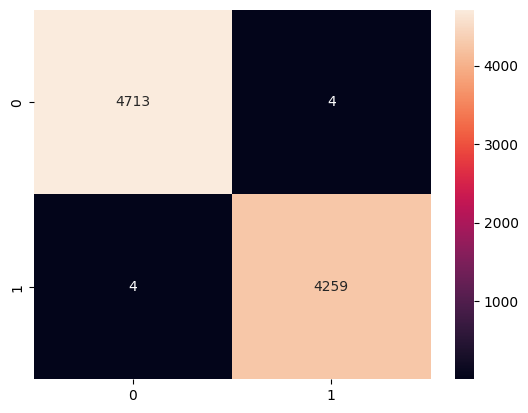

In [ ]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

# **22: Predict New News**

In [ ]:
def predict_news(news):

    encoding = tokenizer(
        news,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)

    attention_mask = encoding["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():

        output = model(
            input_ids,
            attention_mask=attention_mask
        )

        prediction = torch.argmax(
            output.logits,
            dim=1
        )

    return "Real" if prediction.item()==1 else "Fake"

In [ ]:
news = """
NASA successfully launches new satellite into space.
"""

print(
    predict_news(news)
)

Fake


# **23: Save Model**

In [ ]:
model.save_pretrained("fake_news_model")

tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

# **24: Load Model**

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "fake_news_model"
)

tokenizer = BertTokenizer.from_pretrained(
    "fake_news_model"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
import torch

In [ ]:
def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    if prediction == 1:
        print("🟢 Prediction: Real News")
    else:
        print("🔴 Prediction: Fake News")

In [ ]:
predict_news("The Indian government announced a new education policy.")

🔴 Prediction: Fake News


In [ ]:
predict_news("NASA launches a new satellite.")

🔴 Prediction: Fake News


In [ ]:
df.sample(5)

,title,text,subject,date,label
26724,Trump Considers ‘Terminating NAFTA’ With Exec...,donald trump is reportedly considering an exec...,News,"April 26, 2017",0
38804,White House says Obama spoke to Trump by phone...,washington reuters president barack obama spok...,politicsNews,"November 28, 2016",1
33568,AUSTRIAN JUSTICE SYSTEM Gives Teen With Homema...,before we get too far into this story it needs...,left-news,"Feb 6, 2016",0
35938,Congress Passes Monumental Mental Health Refo...,in a rare display of bipartisanship nearly eve...,News,"July 17, 2016",0
1486,British PM May should call a leadership contes...,london reuters british prime minister theresa ...,worldnews,"October 5, 2017",1


In [ ]:
predict_news(df.iloc[100]["text"])

🟢 Prediction: Real News


In [ ]:
df.iloc[107]["text"]

'the washington post just got called out big time on a fake story they published this is a screenshot of the articlethe big lie from washington post president trump revealed highly classified information to the russian foreign minister and ambassador in a white house meeting last week according to current and former us officials who said trump s disclosures jeopardized a critical source of intelligence on the islamic statethe information the president relayed had been provided by a us partner through an intelligencesharing arrangement considered so sensitive that details have been withheld from allies and tightly restricted even within the us government officials saidthey tried to discredit president trump in his dealings with russia by saying president trump revealed highly classified information to the russians not true they got caught and then called out by the trump administration s national security advisorthis is awesomenational security advisor hr mcmaster made a statement sayin

In [ ]:
predict_news(df.iloc[1]["text"])

🟢 Prediction: Real News


In [ ]:
predict_news(df.iloc[18]["text"])

🔴 Prediction: Fake News


In [ ]:
predict_news(df.iloc[1089]["text"])

🟢 Prediction: Real News


In [ ]:
predict_news(df.iloc[1730]["text"])

🔴 Prediction: Fake News


# Conclusion

In this project, I developed a Fake News Detection system using Google's BERT Transformer model.

The project demonstrates the complete Natural Language Processing (NLP) pipeline:

- Data preprocessing and cleaning
- BERT tokenization
- Fine-tuning a pretrained BERT model
- Model evaluation using accuracy, precision, recall, and F1-score
- Predicting whether custom news articles are Real or Fake

This project strengthened my understanding of Deep Learning, Transformer models, transfer learning, and text classification using PyTorch and Hugging Face Transformers.

### Future Improvements

- Deploy the model using Streamlit or Flask
- Extend support for multilingual fake news detection
- Improve model explainability using SHAP or LIME
- Evaluate the model on larger and more diverse datasets